## Classical/Frequentist Statistical Inference


There are three main types of inference
1. Point estimation, asking "what is the best estimate for a model parameter, $\theta$ based on the available data?"
2. Confidence estimation, "How confident we should be in our point estimate?"
3. Hypothesis testing, "Is the data at hand consistent with a given hypothesis or model?"


### Notation

Population is the full distribution/process we wish to understand. Sample is the finite set of measurements that we actually observe

Weirdly, the population doesn't need to be different objects, it can be repeat measurements of the same, stationary source as the measurements are spread by observational uncertainty.

A statistics is a function of the observed sample. E.g sample mean, the first measurement
An estimator is a statistic designed for calculating the estimate of a given quantity based on observed data

Key differences:

Probability definition
 - In frequentist inference, probabilities describe the relative frequency of events over repeated experimental trials.
 - In Bayesian inferenece, probabilities instead quantify our subjective belief about experimental outcomes, model parameters, or even the models themselves.

How to quantify uncertainty
- Frequentist inference has confidence levels that describe the distribution of the measured parameter from the data around the true value
- In Bayesian inference we have credible regions derived from posterior probabilitiy distributions


Here is an example about IQ and is mostly copied from the Bicocca_2026 lecture

The following article provides a nice example that is visualized below (without the detailed math): Efron 1978 ["Controversies in the Foundations of Statistics".](https://www.jstor.org/stable/2321163?seq=1#page_scan_tab_contents)

The IQ of the population has mean of 100 and standard deviation 15. Alice takes a test which returns an IQ of 160. Given these pieces of information, what is the IQ of Alice?

Note Alice takes the test only once. A frequentists would say that 160 is best possibile estimator for Alice's IQ true value. A Bayesian instead would instead conclude Alice had lucky day and her true IQ is lower than 160 because it's very unlikely to get 160 among people that usually get 100.

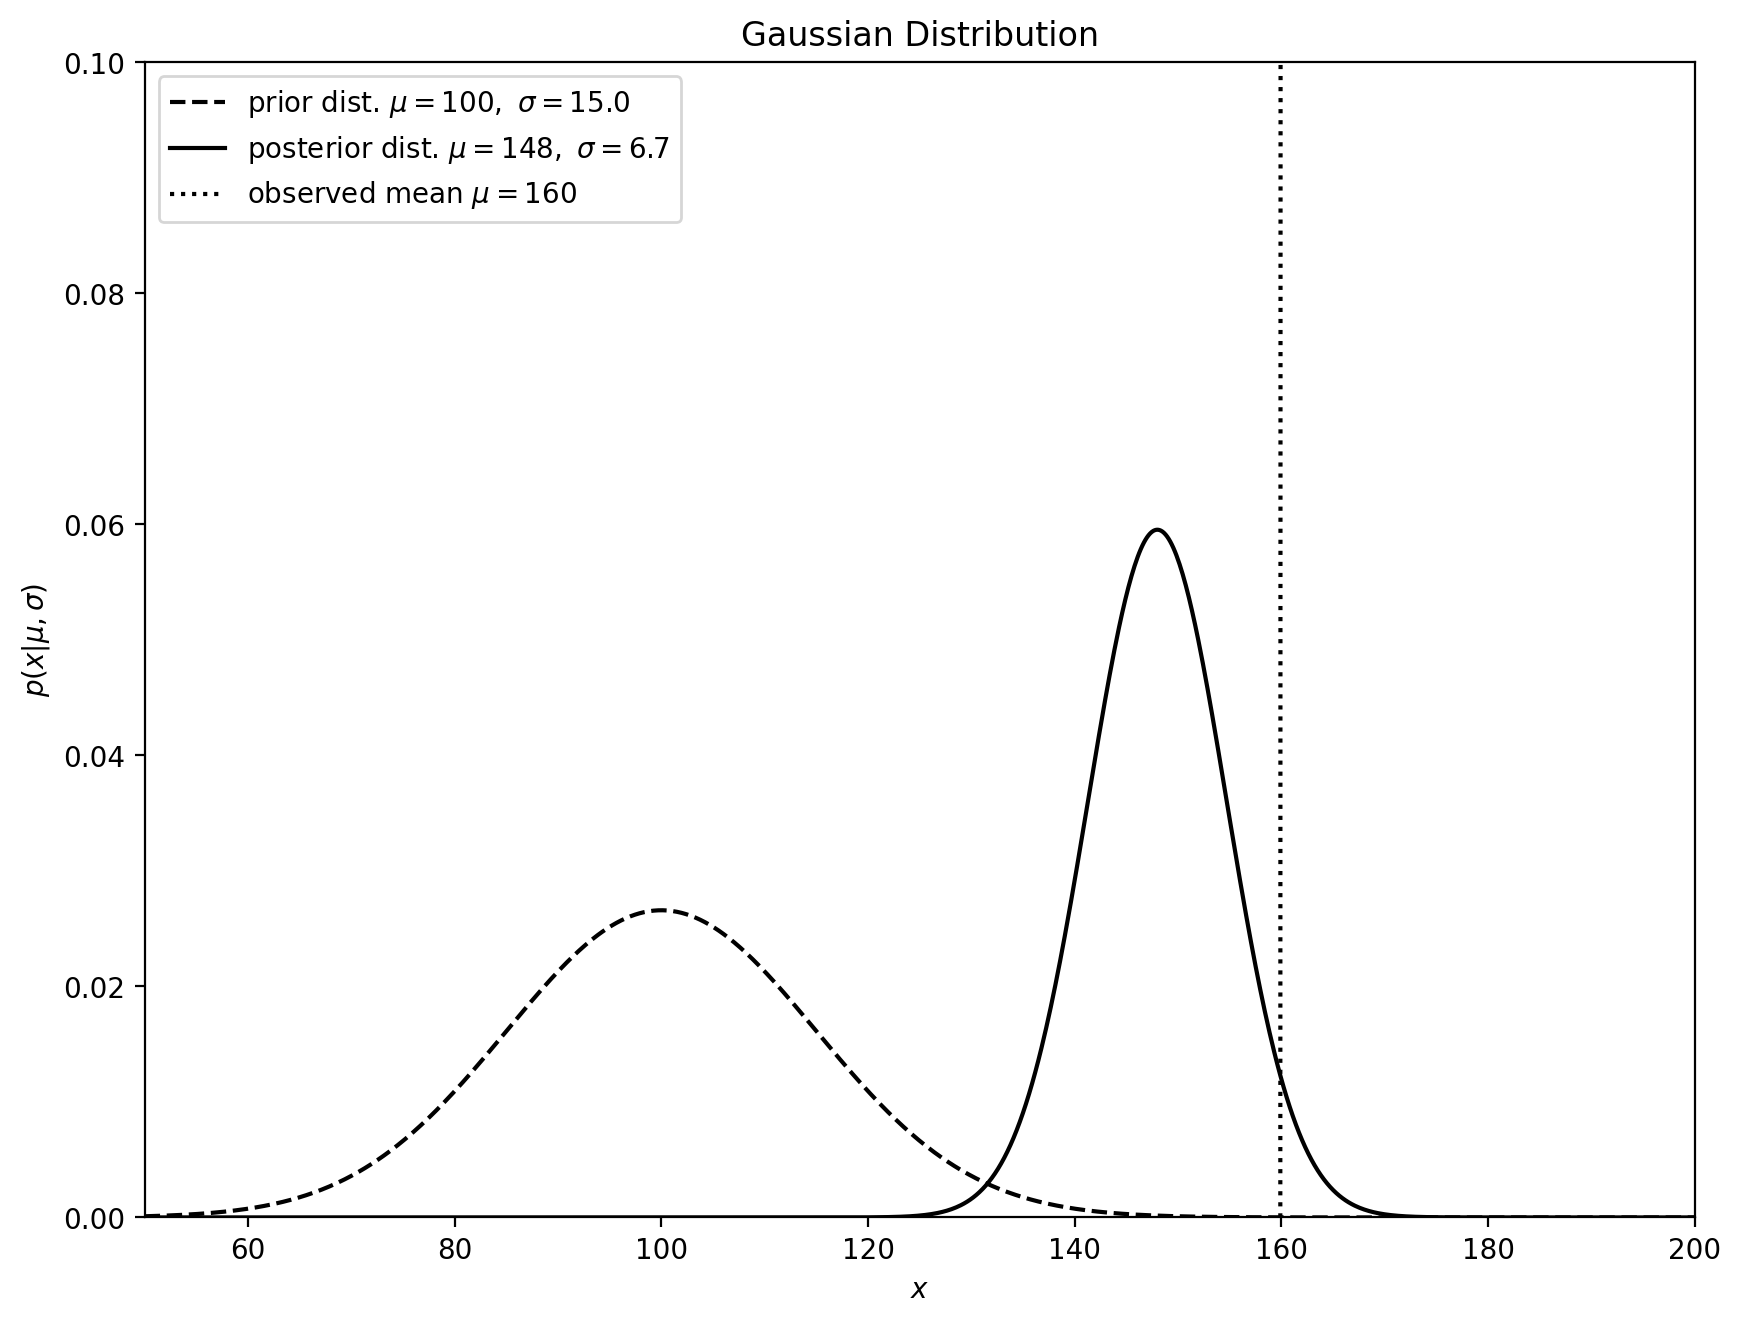

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina' #doubles the resolution of the inline plots

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

#defining distributions to be plotted
sigma_values = [15, 6.7, 1] #complete with the prior width of IQ distribution
linestyles = ['--', '-', ':']
mu_values = [100, 148, 160] #complete with the prior mean of IQ distribution
labeltext = ['prior dist.', 
             'posterior dist.', 
             'observed mean']
xplot = np.linspace(50, 200, 1000)

#plotting distributions

fig,ax = plt.subplots(figsize = (10, 7.5))

for sigma, ls, mu, lab in zip(sigma_values, 
                              linestyles, 
                              mu_values, 
                              labeltext): # iterates over multiple lists simultaneously using zip(), makes individual variables

    
    # create a gaussian / normal distribution
    dist = norm(mu, sigma)

    if sigma > 1: #because a std of less than 1 is very narrow and can cause a delta function like spike
        plt.plot(xplot, dist.pdf(xplot), 
                 ls=ls, c='black',
                 label=r'%s $\mu=%i,\ \sigma=%.1f$' % (lab, mu, sigma))
    else:
        plt.plot([159.9, 160.1], [0, 0.8], 
                 ls=ls, color='k', label=r'%s $\mu=%i$' % (lab, mu))
        
plt.xlim(50, 200)
plt.ylim(0, 0.1)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\mu,\sigma)$')
plt.title('Gaussian Distribution')
plt.legend()

### Maximum likelihood estimation:

Maximum likelihood estimation begins by proposing a model for how the data were generated. The model is described using one or more parameters collected into

\begin{equation}
\boldsymbol{\theta}=(\theta_1,\theta_2,\ldots,\theta_k)
\end{equation}

We have the following frequentists way of maximum likelihood estimation:

- Formulate a model or hypothesis about how the data was generated.
- Find the parameter values that maximise the likelihood, $L = p(D|M(\theta))$. This search creates MLE point estimates, $\theta^0$
- Determine the confidence region for the model parameters, $\theta^0$; bootstrap, jackknife, cross-validation (come back to it later)
- Test whether the observed data are consistent with the model by performing hypothesis tests

If the model fails, the workflow returns to the first step and the model is reconsidered.





### Likelihood function

The likelihood is a function of the data given the parameters, we are trying to find the optimal value for the mean or standard deviation for a distribution given a bunch of observed measurements.

If we observe the complete datatet, assuming they are independant, the joint probability is:

$$L(\theta) = p({x_i}|\theta) = \prod_{i=1}^N p(x_i|\theta)$$

Hence a model can only geta  high likelihood if it explains all observations well. 

If the the data wasn't independant, then we would need to use a covariance structure.

For a gaussian dataset, the likelihood as developed in the lecture,

\begin{equation}
L = \left( \prod_{i=1}^{N} \frac{1}{\sigma \sqrt{2\pi}} \right) \exp\left( -\frac{1}{2} \sum_{i=1}^{N} \left[ \frac{x_i - \mu}{\sigma} \right]^2 \right)
\end{equation}

We can connect this to $\chi^2$, as 

$$\chi^2 = \sum^N_{i=1} \left(\frac{x_i-\mu}{\sigma}\right)^2$$

So for gaussian data, maximising the likelihood is the same as minimising $\chi^2$

### Properties of ML estimators

Assuming the data is drawn from the model:

1. They are consistent estimators. They converge to the true parameter value as $N \rightarrow \infty$
2. They are asymptotically normal estimators: the sampling distribution of the estimator approaches a Gaussian distribution for large N
3. They asymptotically achieve the theoretical minimum possible variance: Achieve best possible uncertainty

### Homoscedastic Gaussian measurements

Homoscedastic means that all the measurements have the same uncertainty

Say we have an experiment that follows:

$$x_i \sim \mathcal{N}(\mu, \sigma^2) $$

We take the log-likelihood of (1) as the likelihood can be very small. To note, constant terms can be ignored as they all have the same effect for the model parameters

$$L(\mu) = \text{constant} - \sum_{i=1}^{N} \frac{(x_i - \mu)^2}{2\sigma^2} $$

Find maximum in the usual way

$$\left. \frac{d\ell}{d\mu} \right|_{\mu = \hat{\mu}} = 0 $$


$$\sum_{i=1}^{N} \frac{x_i - \hat{\mu}}{\sigma^2} = 0$$


$$\hat{\mu} = \frac{1}{N} \sum_{i=1}^{N} x_i = \bar{x} $$

Hence we have found that the sample mean is an ML estimator.

### What about estimate uncertainty?

The uncertainty is captured by the shape and distribution of the likelihood function

Fisher informationn is defined as:

$$I(\theta) = E\left[ \frac{d}{d\theta} \ln(p(x;\theta)) \right]$$

The expected value is with respect to the distribution of x and is large if on average the log-likelihood is very sensitive to a change in the parameter $\theta$. (highly curved)

The fisher information matrix is defined as:

$$
\boxed{
F_{jk}
=
-
\left.
\frac{\partial^2\ln L}
{\partial\theta_j\,\partial\theta_k}
\right|_{\boldsymbol{\theta}=\hat{\boldsymbol{\theta}}}
}
$$

For two parameters, it would look like:


$$F
=
-
\begin{pmatrix}
\dfrac{\partial^2\ln L}{\partial\theta_1^2}
&
\dfrac{\partial^2\ln L}
{\partial\theta_1\partial\theta_2}
\\[1.2em]
\dfrac{\partial^2\ln L}
{\partial\theta_2\partial\theta_1}
&
\dfrac{\partial^2\ln L}{\partial\theta_2^2}
\end{pmatrix}_{\boldsymbol{\theta}=\hat{\boldsymbol{\theta}}}$$






Resources:

[Intro to Prob - Point estimation](https://www.probabilitycourse.com/chapter8/8_2_0_point_estimation.php)

[Maximum likelihood clearly explained](https://www.youtube.com/watch?v=XepXtl9YKwc)

[Fisher information in 5 mins](https://www.youtube.com/watch?v=f_wU0LeNUvE)

[What is fisher information](https://www.youtube.com/watch?v=82molmnRCg0)

